# Notebook for the Income Subgroup Analysis

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# Read Data
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')

df_q1 = data[data["Income quartiles"] == 1]       # 1st quartile
df_q2 = data[data["Income quartiles"] == 2]       # 2nd quartile
df_q3 = data[data["Income quartiles"] == 3]       # 3nd quartile
df_q4 = data[data["Income quartiles"] == 4]       # 4nd quartile

print(df_q1.shape)
print(df_q2.shape)
print(df_q3.shape)
print(df_q4.shape)

(1170, 168)
(1430, 168)
(1681, 168)
(1841, 168)


Mean Happiness level for all quartiles

In [4]:
data.groupby("Income quartiles")["How happy are you?"].mean()

Income quartiles
1    7.140171
2    7.602098
3    7.740631
4    7.980445
Name: How happy are you?, dtype: float64

In [5]:
data.groupby("Income quartiles")["How happy are you?"].value_counts()

Income quartiles  How happy are you?
1                 8                     277
                  7                     203
                  10                    164
                  9                     147
                  5                     130
                  6                     124
                  4                      45
                  3                      39
                  2                      22
                  1                      19
2                 8                     395
                  7                     266
                  9                     256
                  10                    193
                  6                     137
                  5                     116
                  4                      34
                  3                      17
                  2                      10
                  1                       6
3                 8                     513
                  9                    

Happiness Distribution using Histrogram plot

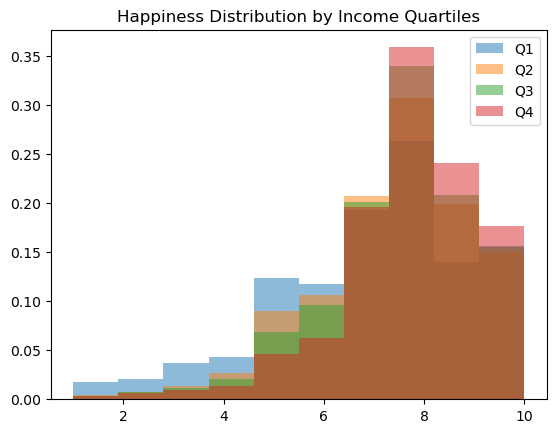

In [5]:
for i, df in enumerate([df_q1, df_q2, df_q3, df_q4], 1):
    plt.hist(df["How happy are you?"], alpha=0.5, label=f"Q{i}", density=True)

plt.legend()
plt.title("Happiness Distribution by Income Quartiles")
plt.show()

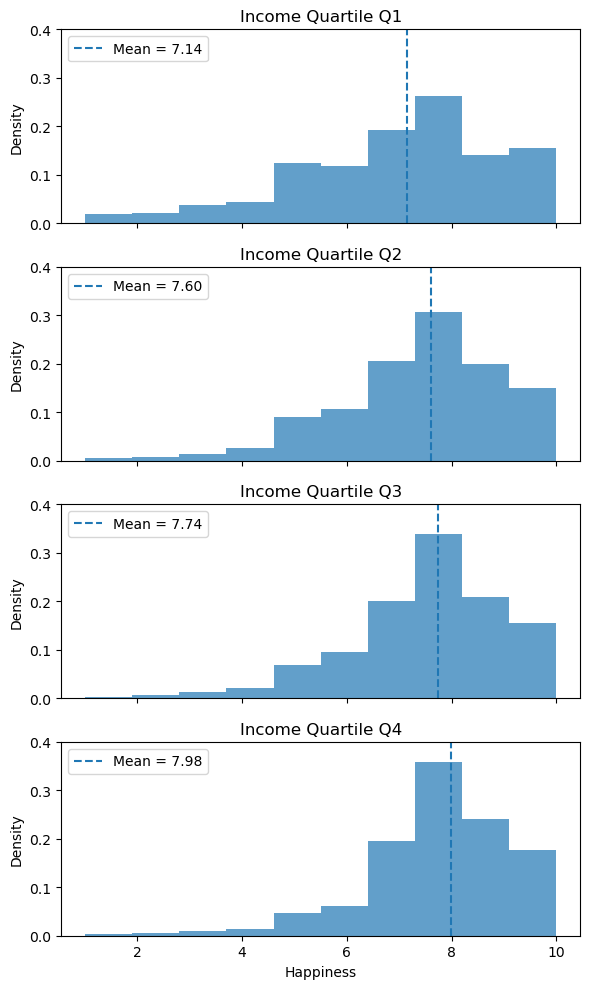

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

dfs = [df_q1, df_q2, df_q3, df_q4]

for i, (ax, df) in enumerate(zip(axes, dfs), 1):
    ax.hist(df["How happy are you?"], alpha=0.7, density=True)
    ax.set_title(f"Income Quartile Q{i}")
    ax.set_ylabel("Density")
    ax.set_ylim(0, 0.4)

    mean = df["How happy are you?"].mean()
    #ax.axvline(mean, linestyle='--', label="Mean")

    ax.axvline(mean, linestyle='--', label=f"Mean = {mean:.2f}")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Happiness")

plt.tight_layout()
plt.show()

Happiness Distribution using Boxplot plot

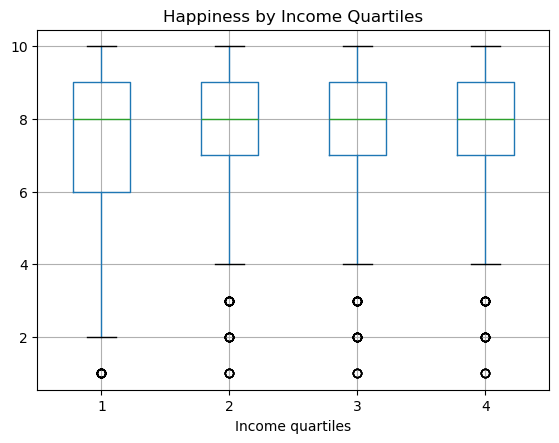

In [10]:
data.boxplot(column="How happy are you?", by="Income quartiles")
plt.title("Happiness by Income Quartiles")
plt.suptitle("")
plt.show()

## Model Training

In [11]:
import importlib
from XGBoost import xgboost_machine_learning
importlib.reload(xgboost_machine_learning)

<module 'XGBoost.xgboost_machine_learning' from 'C:\\Users\\Minh\\Desktop\\Psycho Arbeit\\Psycho_DataspellProjekt\\XGBoost\\xgboost_machine_learning.py'>

Model Settings

In [12]:
my_target_column = "How happy are you?"
my_test_size = 0.2
my_random_state = 42

# Model-specific hyperparameters (baseline defaults)
my_n_estimators = 100
my_max_depth = None

# SHAP settings
my_number_of_shaply_rows = 5000
my_number_header_rows = 150

Run model training and shap

In [13]:
income_groups = {
    "q1": df_q1,
    "q2": df_q2,
    "q3": df_q3,
    "q4": df_q4
}

In [14]:
for name, data in income_groups.items():
    print(f"Running model for {name}...")

    my_target_column = 'How happy are you?'
    print("Shape before: ", data.shape)

    # Drop 'How satisfied with...' columns
    # They have too much predictive value and there are similar questions
    # e.g. "Health condition", "Quality of education system?", "Feel left out of sociey?"
    columns_to_remove = [
        'How satisfied with present standard of living?',
        'How satisfied with family life?',
        'How satisfied with social life?',
        'How satisfied with health?',
        'How satisfied with economic situation in the country?',
        'How satisfied with accommodation?',
        'How satisfied with education?'
    ]
    data.drop(columns=columns_to_remove, inplace=True, errors='ignore')
    print("Shape after: ", data.shape)

    model_1B, shap_results_1B = xgboost_machine_learning.run_xgb_gridsearch_and_shap(
        df=data,
        target_column=my_target_column,
        test_size=my_test_size,
        random_state=my_random_state,
        cv_folds=3,
        shap_rows=my_number_of_shaply_rows,
        number_header_rows=my_number_header_rows
    )

    shap_results_1B.to_csv(f"Results/income_{name}_shap_results_1B_optimized.csv", index=False)

Running model for q1...
Shape before:  (1170, 168)
Shape after:  (1170, 161)
Fitting 3 folds for each of 108 candidates, totalling 324 fits


C:\Users\Minh\AppData\Local\Temp\ipykernel_21272\2349949249.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=columns_to_remove, inplace=True, errors='ignore')



 Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
 Test RMSE: 1.5656
 Test R²: 0.3832
Starting SHAP for 5000 rows...


100%|██████████| 234/234 [00:04<00:00, 51.60it/s]
C:\Users\Minh\AppData\Local\Temp\ipykernel_21272\2349949249.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=columns_to_remove, inplace=True, errors='ignore')



Top SHAP features:
                                             Questions     Value  Direction
100                  Household able to make ends meet?  0.276953  -0.033741
114                   I am optimistic about the future  0.236420  -0.011811
94   Can't find the way because life has become so ...  0.195554  -0.003912
30                                    Health condition  0.188967  -0.031714
99                        Personal financial situation  0.172660   0.005907
..                                                 ...       ...        ...
141                                      Country_Italy  0.000000   0.000000
140                                    Country_Ireland  0.000000   0.000000
139                                    Country_Iceland  0.000000   0.000000
136                                    Country_Germany  0.000000   0.000000
137                                     Country_Greece  0.000000   0.000000

[150 rows x 3 columns]
Running model for q2...
Shape before:  (1430

...


Top SHAP features:
                                             Questions     Value  Direction
116     I feel I am free to decide how to live my life  0.150763   0.013503
114                   I am optimistic about the future  0.148286  -0.001740
30                                    Health condition  0.143374  -0.000187
94   Can't find the way because life has become so ...  0.105300   0.012023
115  I generally feel that what I do in life is wor...  0.092332   0.001991
..                                                 ...       ...        ...
12                                Education - 3 groups  0.000000   0.000000
14                                    Income quartiles  0.000000   0.000000
15                              DV: Rural/urban living  0.000000   0.000000
38        Problems with accommodation - no bath/shower  0.000000   0.000000
69              Child care used in 12 months - refusal  0.000000   0.000000

[150 rows x 3 columns]
Running model for q3...
Shape before:  (1681

100%|██████████| 337/337 [00:06<00:00, 51.63it/s]
C:\Users\Minh\AppData\Local\Temp\ipykernel_21272\2349949249.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=columns_to_remove, inplace=True, errors='ignore')



Top SHAP features:
                                             Questions     Value  Direction
115  I generally feel that what I do in life is wor...  0.219118  -0.031110
30                                    Health condition  0.157469   0.013597
114                   I am optimistic about the future  0.098370   0.005065
95   The value of what I do is not recognised by ot...  0.091092  -0.008791
58                         Quality of health services?  0.085690   0.002843
..                                                 ...       ...        ...
69              Child care used in 12 months - refusal  0.000000   0.000000
37             Problems with accommodation - no toilet  0.000000   0.000000
74          Long term care used in 12 months - refusal  0.000000   0.000000
128                                   Country_Bulgaria  0.000000   0.000000
137                                     Country_Greece  0.000000   0.000000

[150 rows x 3 columns]
Running model for q4...
Shape before:  (1841

100%|██████████| 369/369 [00:07<00:00, 51.49it/s]


Top SHAP features:
                                             Questions     Value  Direction
30                                    Health condition  0.186917  -0.014730
59                        Quality of education system?  0.116789  -0.004748
115  I generally feel that what I do in life is wor...  0.108815   0.011602
94   Can't find the way because life has become so ...  0.094682   0.002454
116     I feel I am free to decide how to live my life  0.071522   0.002926
..                                                 ...       ...        ...
137                                     Country_Greece  0.000000   0.000000
138                                    Country_Hungary  0.000000   0.000000
145                                 Country_Luxembourg  0.000000   0.000000
147                                      Country_Malta  0.000000   0.000000
146                          Country_Macedonia (FYROM)  0.000000   0.000000

[150 rows x 3 columns]


### Plot Results

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

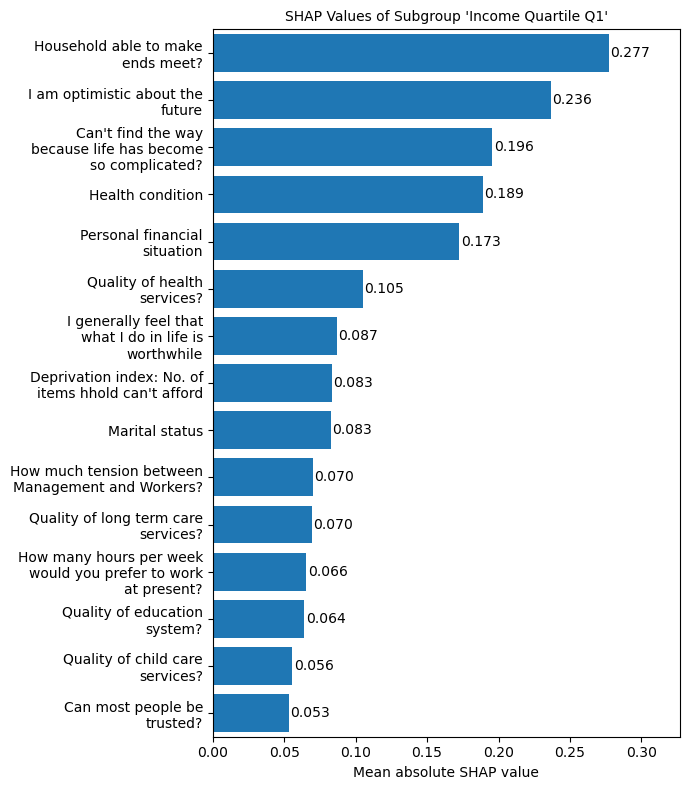

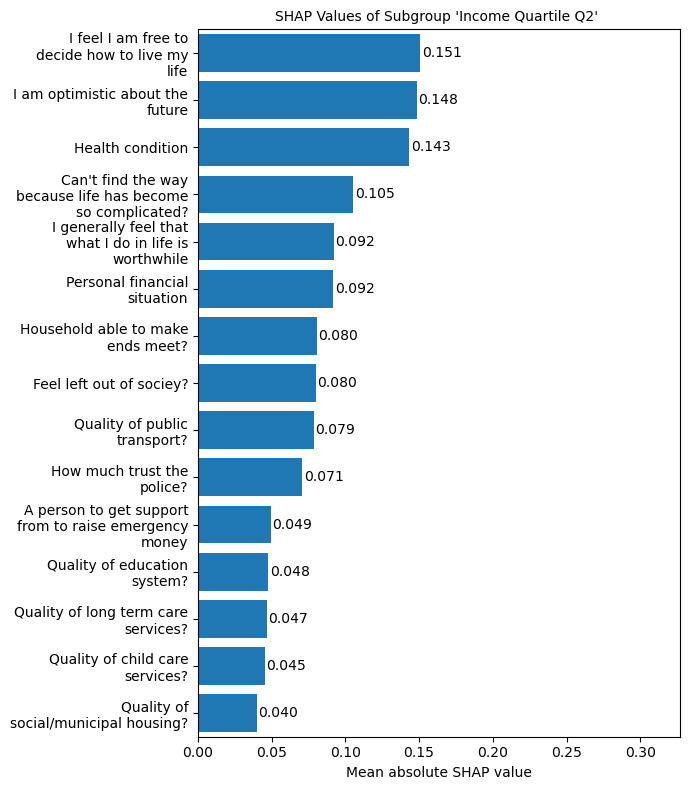

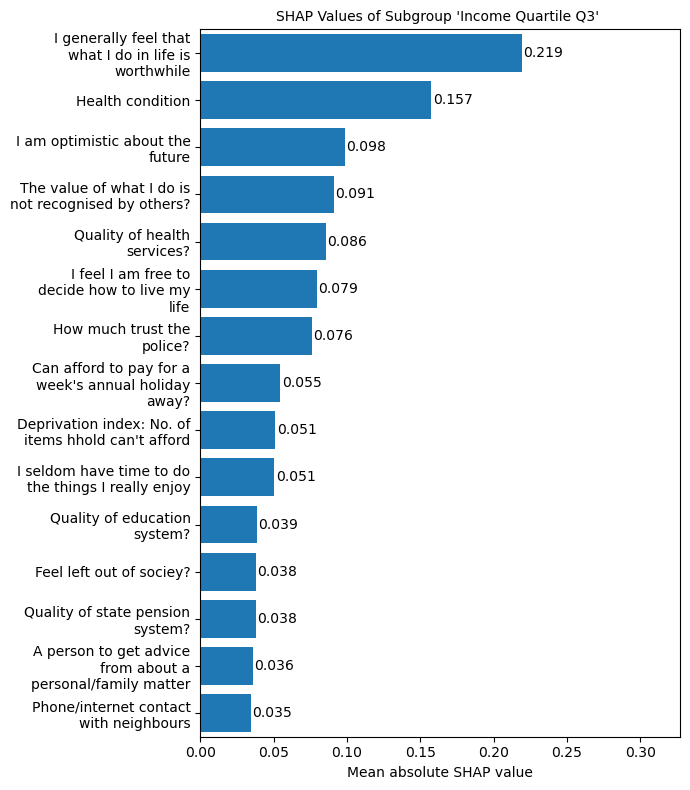

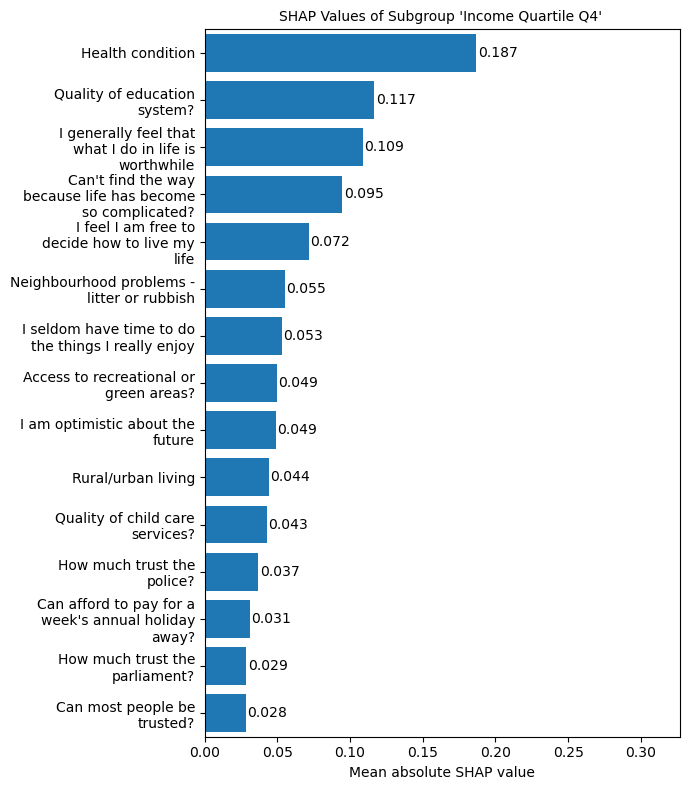

In [32]:
# Load Data
df_q1 = pd.read_csv("Results/income_q1_shap_results_1B_optimized.csv")
df_q2 = pd.read_csv("Results/income_q2_shap_results_1B_optimized.csv")
df_q3 = pd.read_csv("Results/income_q3_shap_results_1B_optimized.csv")
df_q4 = pd.read_csv("Results/income_q4_shap_results_1B_optimized.csv")

def plot_shap_large(df, title, max_questions=None):

    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    #plt.figure(figsize=(5.5, n * 0.6))
    plt.figure(figsize=(7, 8))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_q1["Value"].max(),
        df_q2["Value"].max(),
        df_q3["Value"].max(),
        df_q4["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)

    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_q1, "SHAP Values of Subgroup 'Income Quartile Q1'", max_questions=15)
plot_shap_large(df_q2, "SHAP Values of Subgroup 'Income Quartile Q2' ", max_questions=15)
plot_shap_large(df_q3, "SHAP Values of Subgroup 'Income Quartile Q3' ", max_questions=15)
plot_shap_large(df_q4, "SHAP Values of Subgroup 'Income Quartile Q4' ", max_questions=15)
plt.show()